Subject: sub-01  |  run: c  (eyes_closed)

📊 L_M1
  → iEEG: ECOG-8-9-L @ 250.0 Hz


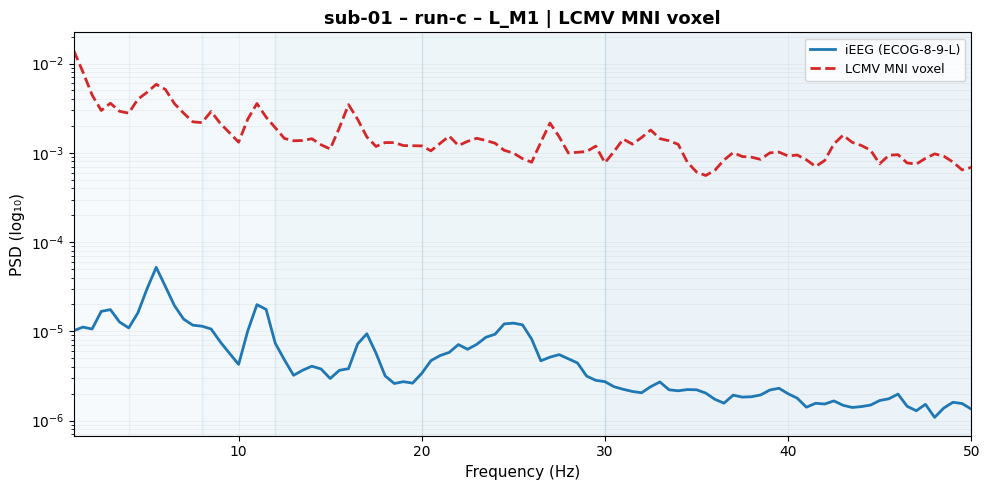


📊 R_M1
  → iEEG: ECOG-8-9-R @ 250.0 Hz


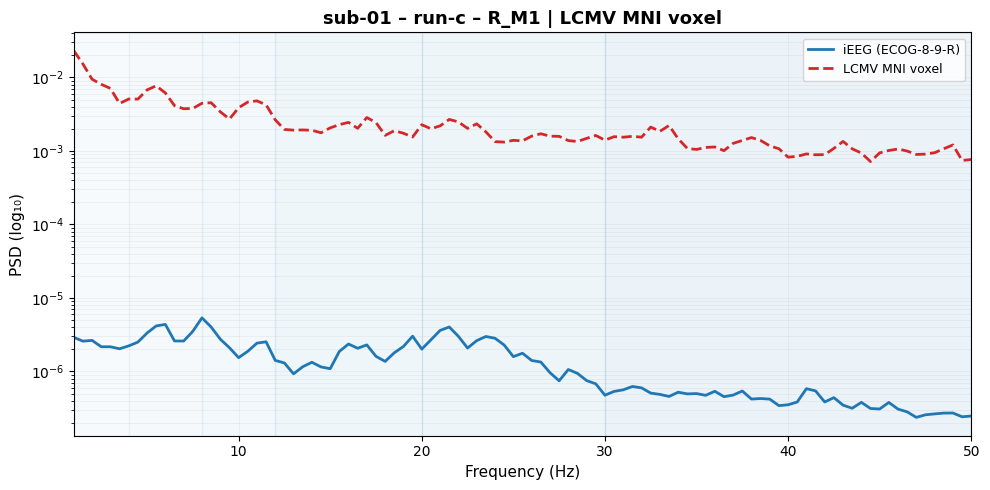


📊 L_STN
  → iEEG: STN-L @ 250.0 Hz


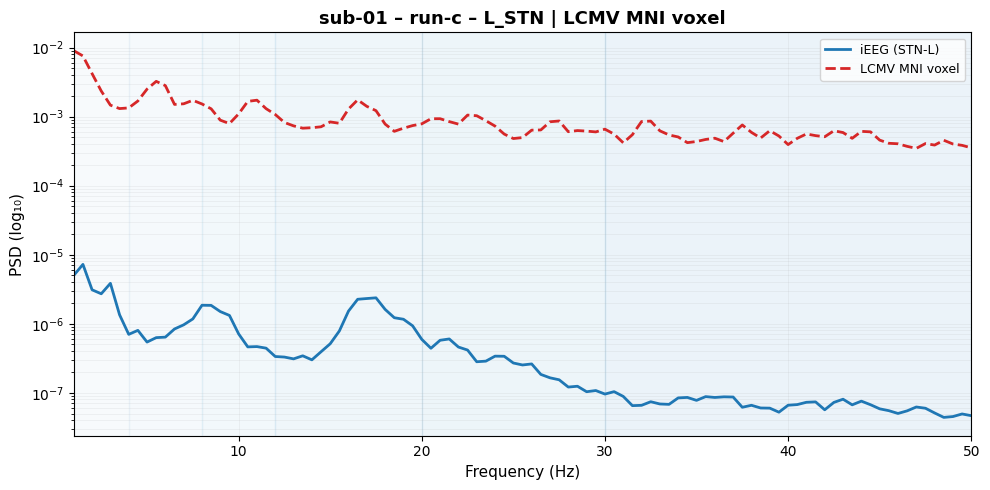

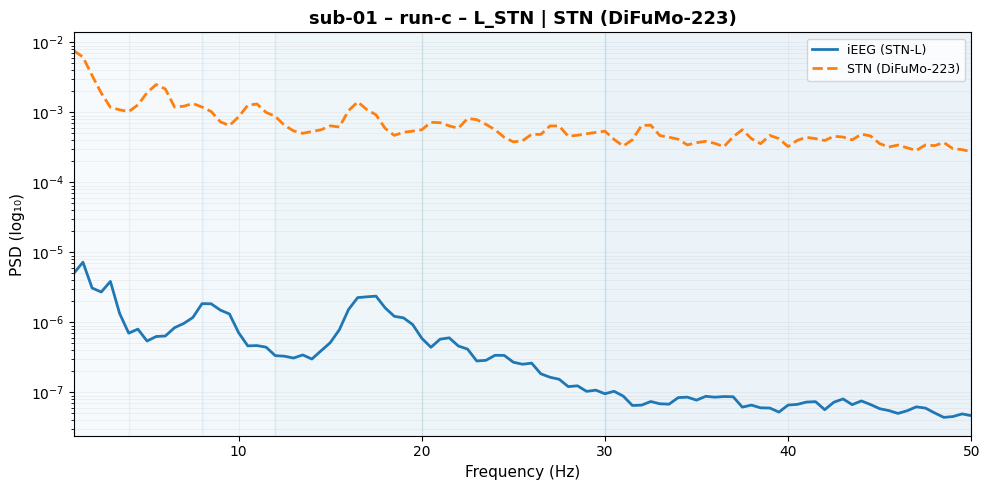

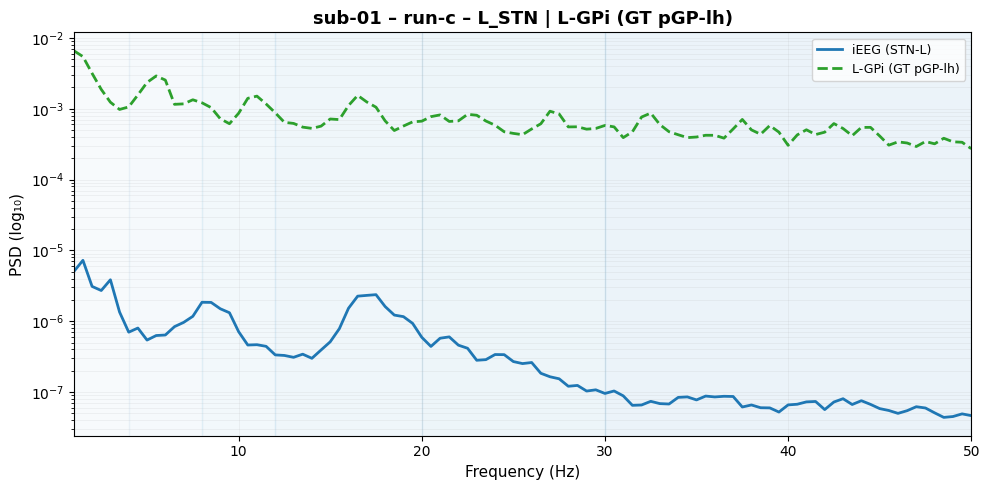


📊 R_STN
  → iEEG: STN-R @ 250.0 Hz


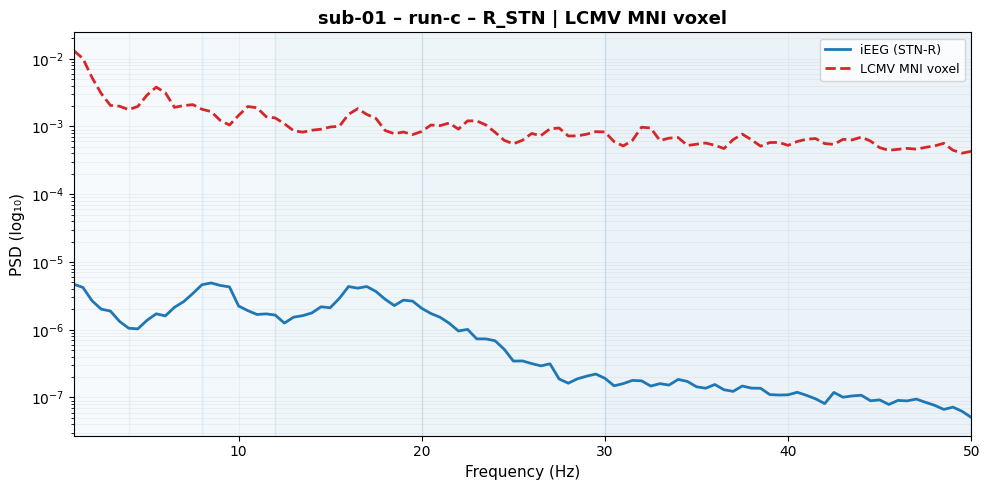

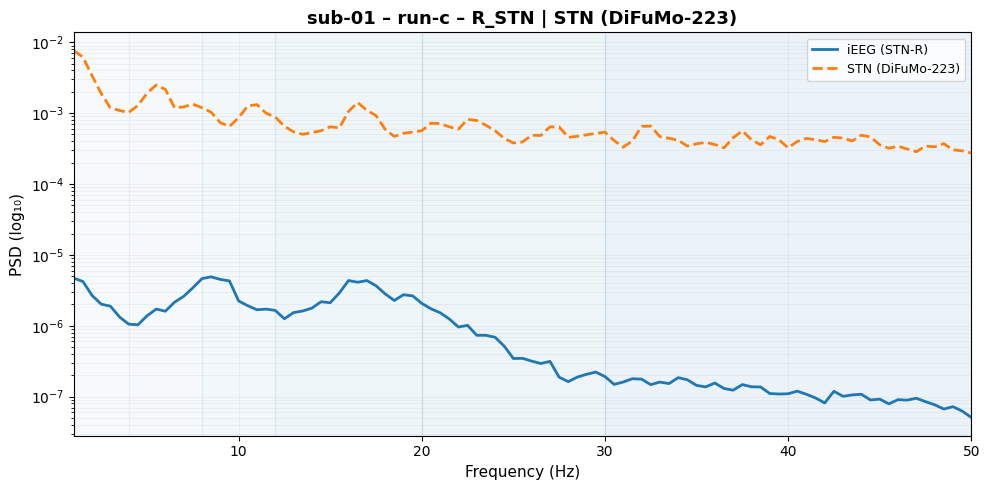

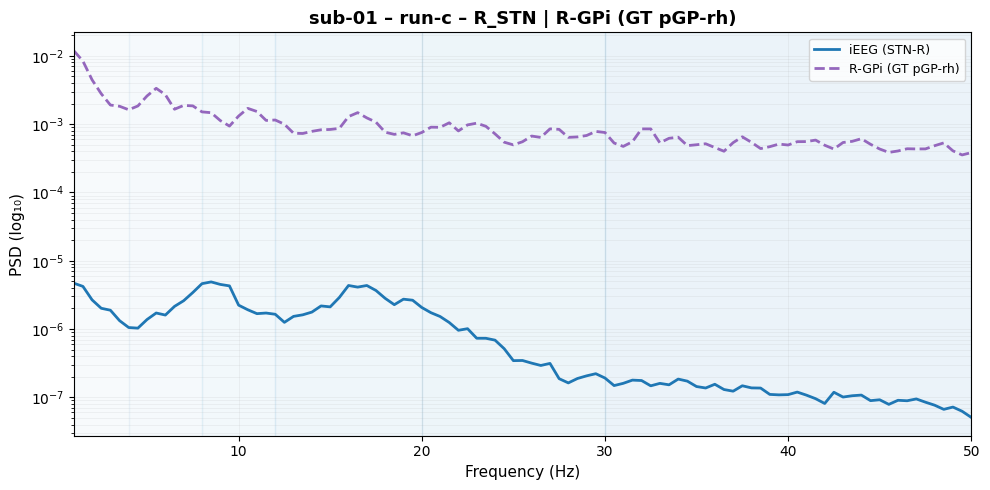


✅ Done.


In [1]:
"""
validate_npz.py

Exact same plot_comparison() style as original Script 1.
For L_STN / R_STN produces 3 separate figures:
  1. iEEG  vs  LCMV MNI voxel
  2. iEEG  vs  STN DiFuMo-223
  3. iEEG  vs  L_GPi / R_GPi (GT atlas)

For L_M1 / R_M1 produces 1 figure:
  1. iEEG  vs  LCMV MNI voxel

Set RUN below to one of: c, o, l, r
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import trapezoid
import scipy.signal as signal

# =============================================================================
# CONFIGURATION
# =============================================================================

SUBJECT = "sub-01"
RUN     = "c"   # one of: c, o, l, r

RUN_TO_COND = {
    "c": "eyes_closed",
    "o": "eyes_open",
    "l": "left_hand",
    "r": "right_hand",
}

NPZ_PATH  = Path(f"/mnt/movement/users/jaizor/xtra/derivatives/integrated/lcmv/{SUBJECT}_rois.npz")
IEEG_FILE = Path(f"/mnt/movement/users/jaizor/xtra/derivatives/dbs/trials/rest_off/{SUBJECT}/rest_off_{SUBJECT}_{RUN}_ieeg.npz")

# For each ROI: iEEG channels + which atlas ROIs to compare separately
ROI_CONFIG = {
    "L_M1":  {"ieeg_ch": ["ECOG-8-9-L", "ECOG-10-11-L"], "atlas": []},
    "R_M1":  {"ieeg_ch": ["ECOG-8-9-R", "ECOG-10-11-R"], "atlas": []},
    "L_STN": {"ieeg_ch": ["STN-L"],                       "atlas": ["STN", "L_GPi"]},
    "R_STN": {"ieeg_ch": ["STN-R"],                       "atlas": ["STN", "R_GPi"]},
}

ATLAS_LABELS = {
    "STN":   "STN (DiFuMo-223)",
    "L_GPi": "L-GPi (GT pGP-lh)",
    "R_GPi": "R-GPi (GT pGP-rh)",
}

ATLAS_COLORS = {
    "STN":   "#ff7f0e",
    "L_GPi": "#2ca02c",
    "R_GPi": "#9467bd",
}

# =============================================================================
# PSD — verbatim from original Script 1
# =============================================================================

SFREQ_DEFAULT  = 500.0
PSD_WINDOW_SEC = 2.0
FMAX           = 50    # change to 100 to see full spectrum

FREQ_BANDS = {
    'Delta':      (1,  4),
    'Theta':      (4,  8),
    'Alpha':      (8,  12),
    'Low_Beta':   (12, 20),
    'High_Beta':  (20, 30),
    'Low_Gamma':  (30, 50),
    'High_Gamma': (50, 100),
}

def _compute_band_powers(freqs: np.ndarray, psd: np.ndarray) -> dict:
    band_powers = {}
    df = freqs[1] - freqs[0]
    for band, (fmin, fmax) in FREQ_BANDS.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        if np.any(mask):
            band_powers[band] = trapezoid(psd[mask], dx=df)
        else:
            band_powers[band] = 0.0
    return band_powers

def compute_psd(time_series: np.ndarray, sfreq: float = SFREQ_DEFAULT, method: str = 'welch',
                fmin: float = 1.0, fmax: float = 100.0, window_sec: float = PSD_WINDOW_SEC):
    ts = np.real(time_series).astype(np.float64)
    window_size = int(window_sec * sfreq)
    if len(ts) < window_size:
        raise ValueError("Time series too short")
    nyq = sfreq * 0.5
    b, a = signal.butter(4, 0.5 / nyq, btype='high')
    filtered = signal.filtfilt(b, a, ts)
    if method == 'welch':
        freqs, psd = signal.welch(filtered, fs=sfreq, window='hann', nperseg=window_size,
                                   noverlap=window_size // 2, detrend='constant')
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs, psd = freqs[mask], psd[mask]
    else:
        raise ValueError("Only 'welch' supported in this script")
    band_powers = _compute_band_powers(freqs, psd)
    return freqs.astype(np.float32), psd.astype(np.float32), band_powers

# =============================================================================
# LOADERS
# =============================================================================

def load_ieeg(ieeg_path: Path):
    npz  = np.load(ieeg_path, allow_pickle=True)
    meta = npz['trial_metadata'].item()
    channels = {k: npz[k] for k in npz.files if k != 'trial_metadata'}
    return channels, meta

# =============================================================================
# PLOT — verbatim style from original Script 1
# =============================================================================

def plot_comparison(roi_name, ieeg_signal, ieeg_sfreq, ch_used,
                    source_signal, source_sfreq,
                    source_label='Source Reconstruction',
                    source_color='#d62728'):
    freqs_ieeg, psd_ieeg, _ = compute_psd(ieeg_signal, sfreq=ieeg_sfreq, fmax=FMAX)
    freqs_src,  psd_src,  _ = compute_psd(source_signal, sfreq=source_sfreq, fmax=FMAX)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(freqs_ieeg, psd_ieeg, color='#1f77b4', linewidth=2.0,
            label=f'iEEG ({ch_used})')
    ax.plot(freqs_src,  psd_src,  color=source_color, linewidth=2.0,
            linestyle='--', label=source_label)

    # Band shading — exactly as original
    cmap    = plt.colormaps.get_cmap("Blues")
    n_bands = len(FREQ_BANDS)
    for i, (band, (fmin, fmax)) in enumerate(FREQ_BANDS.items()):
        if fmax < freqs_ieeg[0] or fmin > freqs_ieeg[-1]:
            continue
        color_intensity = 0.3 + (i / max(n_bands - 1, 1)) * 0.4
        band_color = cmap(color_intensity)
        band_low   = max(fmin, freqs_ieeg[0])
        band_high  = min(fmax, freqs_ieeg[-1])
        ax.axvspan(band_low, band_high, color=band_color, alpha=0.10, zorder=0)

    ax.set_xlabel("Frequency (Hz)", fontsize=11)
    ax.set_ylabel("PSD (log₁₀)", fontsize=11)
    ax.set_yscale('log')
    ax.set_xlim(1, FMAX)
    ax.grid(True, which='both', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.legend(fontsize=9)
    ax.set_title(f"{SUBJECT} – run-{RUN} – {roi_name} | {source_label}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# MAIN
# =============================================================================

if __name__ == '__main__':
    if not IEEG_FILE.exists():
        raise FileNotFoundError(f"iEEG file not found: {IEEG_FILE}")
    if not NPZ_PATH.exists():
        raise FileNotFoundError(f"NPZ not found: {NPZ_PATH}")

    cond = RUN_TO_COND[RUN]
    print(f"Subject: {SUBJECT}  |  run: {RUN}  ({cond})")

    ieeg_ch, ieeg_meta = load_ieeg(IEEG_FILE)
    ieeg_sfreq = ieeg_meta['sfreq']

    npz        = np.load(NPZ_PATH, allow_pickle=True)
    meta       = npz["metadata"].item()
    lcmv_sfreq = meta["sfreq"]

    for roi_name, config in ROI_CONFIG.items():
        print(f"\n📊 {roi_name}")

        # --- iEEG ---
        ieeg_signal, ch_used = None, None
        for ch in config["ieeg_ch"]:
            if ch in ieeg_ch:
                ieeg_signal = ieeg_ch[ch]
                ch_used     = ch
                break
        if ieeg_signal is None:
            print(f"  ⚠️ No iEEG channel found for {roi_name}")
            continue
        print(f"  → iEEG: {ch_used} @ {ieeg_sfreq} Hz")

        # Figure 1 — iEEG vs LCMV MNI voxel
        lcmv_key = f"{roi_name}_{cond}"
        if lcmv_key in npz:
            plot_comparison(roi_name, ieeg_signal, ieeg_sfreq, ch_used,
                            npz[lcmv_key], lcmv_sfreq,
                            source_label='LCMV MNI voxel',
                            source_color='#d62728')
        else:
            print(f"  ⚠️ Key not found in NPZ: {lcmv_key}")

        # Figure 2, 3, ... — iEEG vs each atlas ROI separately
        for atlas_key in config["atlas"]:
            npz_key = f"{atlas_key}_{cond}"
            if npz_key in npz:
                plot_comparison(roi_name, ieeg_signal, ieeg_sfreq, ch_used,
                                npz[npz_key], lcmv_sfreq,
                                source_label=ATLAS_LABELS[atlas_key],
                                source_color=ATLAS_COLORS[atlas_key])
            else:
                print(f"  ⚠️ Atlas key not found: {npz_key}")

    print("\n✅ Done.")